In [4]:
from langchain_openai import ChatOpenAI
from langgraph.graph import add_messages, START,END, StateGraph

from typing import Annotated
from typing_extensions import TypedDict
import dotenv
dotenv.load_dotenv()

True

In [3]:
class State(TypedDict):
    messages:Annotated[list,add_messages]

In [5]:
llm = ChatOpenAI(model = "gemini-2.5-flash")

In [11]:
def chatbot(state:State):
    return {"messages":llm.invoke(state["messages"])}

In [12]:
graph_builder = StateGraph(State)
graph_builder.add_node("llm_chatbot",chatbot)

graph_builder.add_edge(START,"llm_chatbot")
graph_builder.add_edge("llm_chatbot",END)

graph = graph_builder.compile()

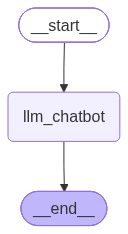

In [13]:
from IPython.display import Image,display
display(Image(graph.get_graph().draw_mermaid_png()))

In [14]:
graph.invoke({"messages":"hi"})

{'messages': [HumanMessage(content='hi', additional_kwargs={}, response_metadata={}, id='1d265e92-c4e9-487e-933f-8827a0e010e0'),
  AIMessage(content='Hi there! How can I help you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 238, 'prompt_tokens': 2, 'total_tokens': 240, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': None, 'reasoning_tokens': 228, 'rejected_prediction_tokens': None}, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': None, 'text_tokens': 2, 'image_tokens': None}}, 'model_provider': 'openai', 'model_name': 'gemini-2.5-flash', 'system_fingerprint': None, 'id': 'k310aq3sF5PpjrEP4py06Ac', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019fd70a-859f-73f1-9501-d2363b7cf966-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 2, 'output_tokens': 238, 'total_tokens': 240, 'input_token_details': {}, 'output_token_details': {'reasoning': 228}})]}

## ReACT FrameWork

In [3]:
from langchain_openai import ChatOpenAI
from langgraph.graph import START,END,StateGraph,add_messages
from langgraph.prebuilt import ToolNode,tools_condition
from langchain_tavily import TavilySearch

from typing_extensions import TypedDict
from typing import Annotated

from dotenv import load_dotenv
load_dotenv()

True

In [4]:
class State(TypedDict):
    messages:Annotated[list,add_messages]

In [5]:
llm = ChatOpenAI(model="gpt-4.1-nano")

In [6]:
web_search = TavilySearch(max_results=5)

In [7]:
def multiply(a, b):
    """
    input: 
        a: real number
        b: real number

    output:
        Multiplication of a and b i.e. a*b
    """
    return a*b

In [8]:
tools = [web_search,multiply]
llm_with_tools = llm.bind_tools(tools)
llm_with_tools

_ChatModelBinding(bound=ChatOpenAI(metadata={'lc_versions': {'langchain-core': '1.4.8', 'langchain': '1.3.11', 'langchain-openai': '1.3.3'}}, output_version=None, profile={'name': 'GPT-4.1 nano', 'release_date': '2025-04-14', 'last_updated': '2025-04-14', 'open_weights': False, 'max_input_tokens': 1047576, 'max_output_tokens': 32768, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'structured_output': True, 'attachment': True, 'temperature': True, 'image_url_inputs': True, 'pdf_inputs': True, 'pdf_tool_message': True, 'image_tool_message': True, 'tool_choice': True, 'tool_call_streaming': True}, client=<openai.resources.chat.completions.completions.Completions object at 0x000001F525F823C0>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x000001F525F82E40>, root_cli

In [9]:
def chatbot(state:State):
    response = llm_with_tools.invoke(state["messages"])
    return {"messages":response}

In [10]:
graph_builder = StateGraph(State)

graph_builder.add_node("brain_with_tools",chatbot)
graph_builder.add_node("tools",ToolNode(tools))

#ReACT Framework
graph_builder.add_edge(START,"brain_with_tools")
graph_builder.add_conditional_edges("brain_with_tools",tools_condition)
graph_builder.add_edge("tools","brain_with_tools")
graph = graph_builder.compile()

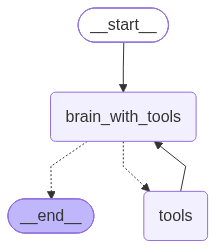

In [11]:
from IPython.display import display,Image

display(Image(graph.get_graph().draw_mermaid_png()))


In [12]:
response1 = graph.invoke({"messages":"what is the current indian stock market news"})

KeyboardInterrupt: 

In [ ]:
response1

{'messages': [HumanMessage(content='what is the current indian stock market news', additional_kwargs={}, response_metadata={}, id='f9fd80c5-f7ee-4465-bdf4-4630d371485f'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 25, 'prompt_tokens': 1238, 'total_tokens': 1263, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0, 'text_tokens': None, 'image_tokens': None}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1-nano-2025-04-14', 'system_fingerprint': 'fp_4d6acce3c3', 'id': 'chatcmpl-EA5lhUuUdDOY9uWB5DMg6BNanN2mI', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019fda50-dac7-7362-b869-a7b5468a845c-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': 'current Indian stock market news', 'search_depth': 'advanced'}, 'id': '

In [ ]:
response1["messages"][-1].pretty_print()

================================== Ai Message ==================================

The Indian stock market has been performing positively recently. The Sensex and Nifty 50 have been on an upward trend, supported by encouraging earnings reports and global market cues. Specifically, on August 3, 2026, the Sensex closed about 540 points higher, and the Nifty 50 ended above 24,770, reaching near its recent highs. 

The market was boosted by falling crude oil prices, easing geopolitical tensions, and strong quarterly earnings from major companies like Bajaj Finance, Bajaj Finserv, and others. The overall sentiment indicates a recovery after recent volatility, with the indices gaining more than 2% in July and maintaining an upward momentum. 

For detailed updates, you can visit sources like Live Mint, Times of India, and Moneycontrol.


In [ ]:
response2 = graph.invoke({"messages":"hi"})

In [ ]:
response2

{'messages': [HumanMessage(content='hi', additional_kwargs={}, response_metadata={}, id='4a24ecee-9e99-4430-88f9-d2a3ff4b9d0e'),
  AIMessage(content='Hello! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 10, 'prompt_tokens': 1231, 'total_tokens': 1241, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0, 'text_tokens': None, 'image_tokens': None}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1-nano-2025-04-14', 'system_fingerprint': 'fp_4d6acce3c3', 'id': 'chatcmpl-EA5mUFte1Nb6omisUX05NJII3wOqQ', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019fda51-9c57-79e1-8698-05d230e52c67-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1231, 'output_tokens': 10, 'total_tokens': 1241, 'input_token_details': 

## Adding Memory

In [48]:
from langgraph.checkpoint.memory import MemorySaver

In [54]:
mem_graph = graph_builder.compile(checkpointer=MemorySaver())

In [55]:
user1 = {"configurable":{"thread_id":"user_1"}}
user2 = {"configurable":{"thread_id":"user_2"}}

In [56]:
user1_res = mem_graph.invoke({"messages":"Hi my name is kishore."}, config = user1)

In [57]:
user1_res

{'messages': [HumanMessage(content='Hi my name is kishore.', additional_kwargs={}, response_metadata={}, id='9035c52a-206f-4c19-a614-49d771a795eb'),
  AIMessage(content='Hello Kishore! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 12, 'prompt_tokens': 1237, 'total_tokens': 1249, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 1152, 'text_tokens': None, 'image_tokens': None}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1-nano-2025-04-14', 'system_fingerprint': 'fp_4d6acce3c3', 'id': 'chatcmpl-EA60K5kisWOgr8vmQ6u2BLH3Tr6HD', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019fda5e-afe1-7c92-940f-f9ef7be6237f-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1237, 'output_tokens': 12, 'total_tokens'

In [58]:
user2_res = mem_graph.invoke({"messages":"What is my name?"}, config=user2)

In [59]:
user2_res

{'messages': [HumanMessage(content='What is my name?', additional_kwargs={}, response_metadata={}, id='b81fb537-8b26-4e6e-bc13-b756cda375fa'),
  AIMessage(content="I don't know your name. Could you please tell me?", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 13, 'prompt_tokens': 1235, 'total_tokens': 1248, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 1152, 'text_tokens': None, 'image_tokens': None}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1-nano-2025-04-14', 'system_fingerprint': 'fp_4d6acce3c3', 'id': 'chatcmpl-EA644qhTQPCsEcQnqjxqQtL8KJ3bL', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019fda62-3c5a-7292-8efc-124c23717ece-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1235, 'output_tokens': 13, 'total_tokens

In [60]:
mem_graph.invoke({"messages":"What is my name?"}, config = user1)

{'messages': [HumanMessage(content='Hi my name is kishore.', additional_kwargs={}, response_metadata={}, id='9035c52a-206f-4c19-a614-49d771a795eb'),
  AIMessage(content='Hello Kishore! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 12, 'prompt_tokens': 1237, 'total_tokens': 1249, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 1152, 'text_tokens': None, 'image_tokens': None}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1-nano-2025-04-14', 'system_fingerprint': 'fp_4d6acce3c3', 'id': 'chatcmpl-EA60K5kisWOgr8vmQ6u2BLH3Tr6HD', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019fda5e-afe1-7c92-940f-f9ef7be6237f-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1237, 'output_tokens': 12, 'total_tokens'